In [1]:
import pandas as pd 

# EDA

In [2]:
# load the data
df = pd.read_csv("./data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [6]:
# check for missing values
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

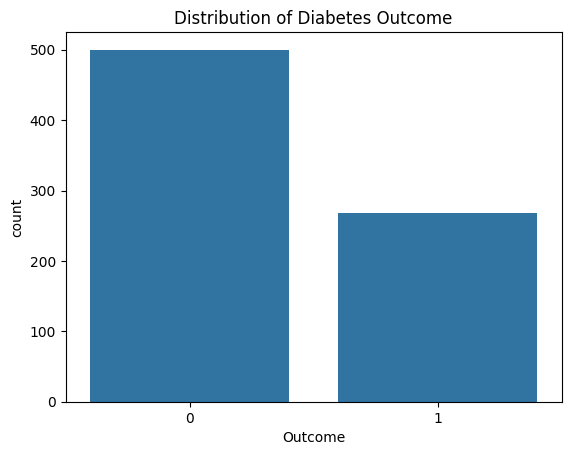

In [7]:
# check for target/class imbalance with plot 
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Outcome", data=df)
plt.title("Distribution of Diabetes Outcome")
plt.show()


In [8]:
# zero values in some columns may indicate missing data, so we can check for that as well
columns_with_zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Age"]
for column in columns_with_zero_as_missing:
    num_zero_values = (df[column] == 0).sum()
    print(f"Number of zero values in {column}: {num_zero_values}")
    

Number of zero values in Glucose: 5
Number of zero values in BloodPressure: 35
Number of zero values in SkinThickness: 227
Number of zero values in Insulin: 374
Number of zero values in BMI: 11
Number of zero values in Age: 0


In [9]:
# replace zero values with NaN for the columns where zero indicates missing data
import numpy as np
for column in columns_with_zero_as_missing:
    df[column] = df[column].replace(0, np.nan)
# check the number of missing values again after replacement
df.isnull().sum()


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

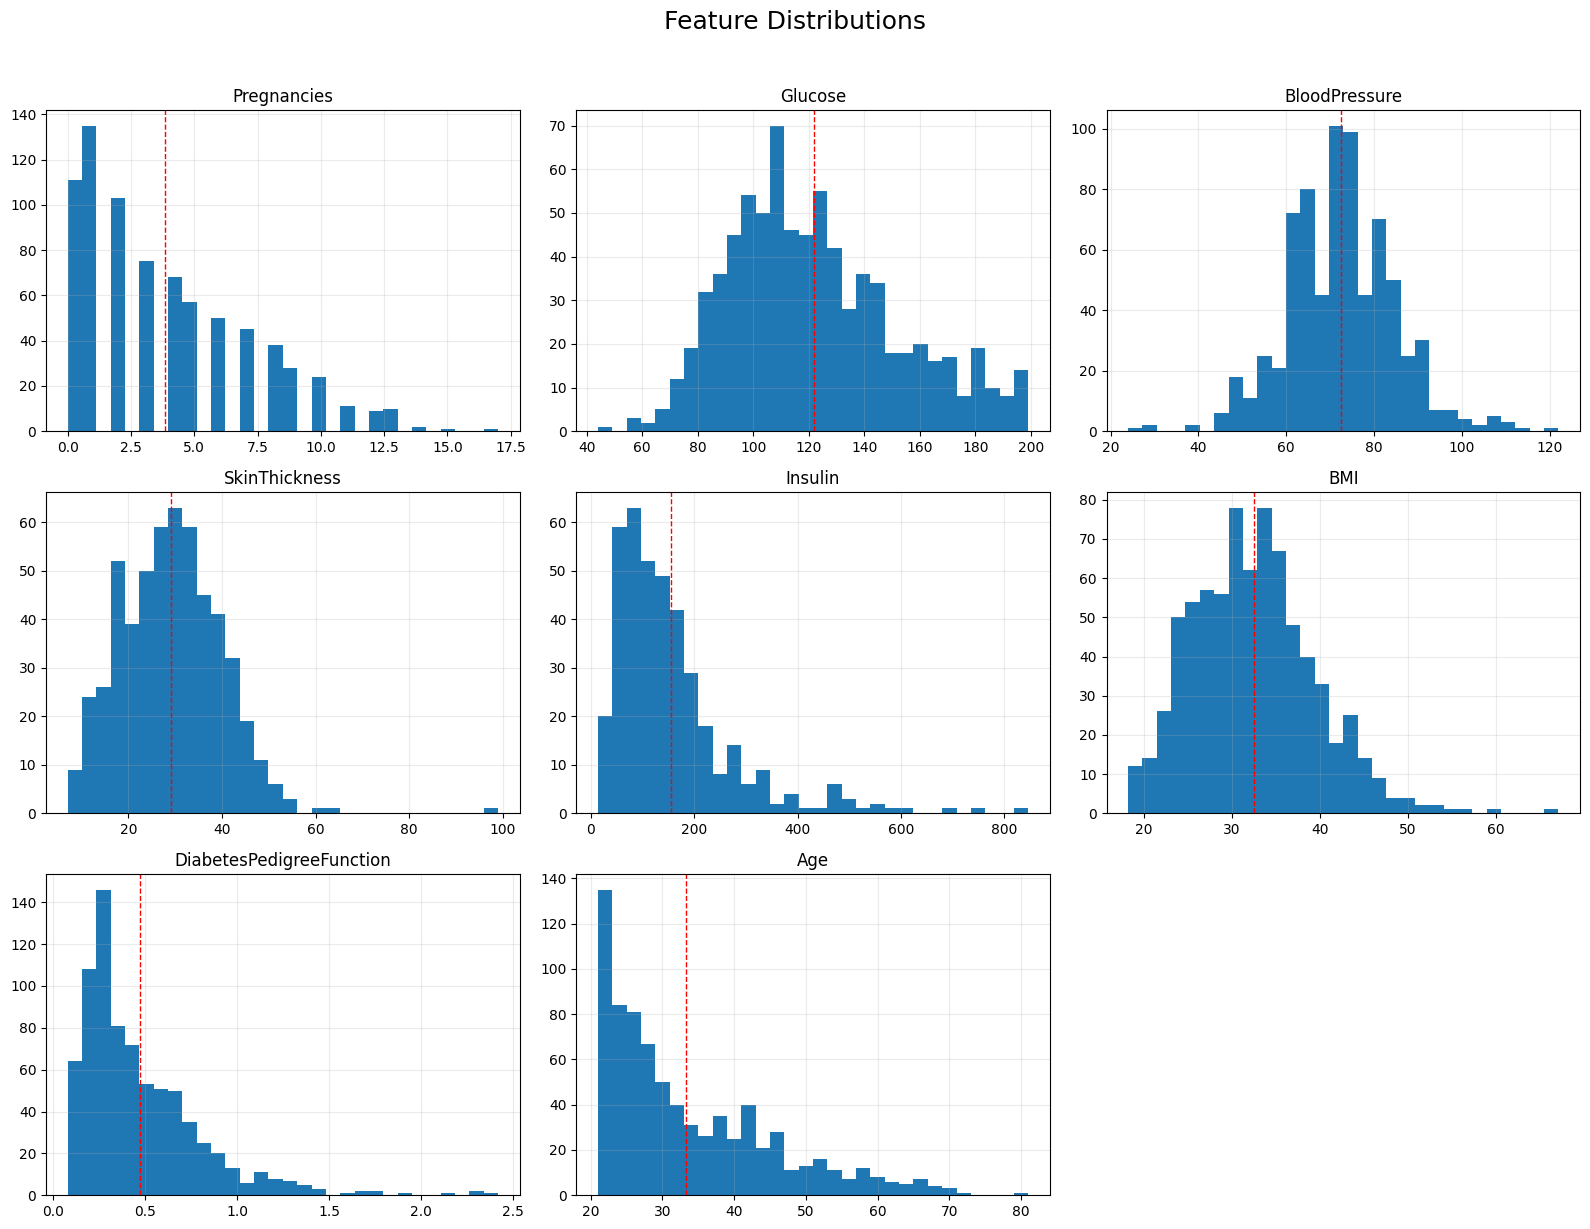

In [10]:
import numpy as np
import matplotlib.pyplot as plt


features = df.columns[:-1]  # exclude target column (Outcome)

n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

fig.suptitle("Feature Distributions", fontsize=18, y=1.02)

for i, feature in enumerate(features):
    ax = axes[i]
    x = df[feature].dropna()

    ax.hist(x, bins=30)  # consistent bins
    ax.set_title(feature, fontsize=12)
    ax.grid(True, alpha=0.25)

    # Optional: add mean line
    ax.axvline(x.mean(), linestyle="--", linewidth=1, color="red")

# Turn off empty axes (if any)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

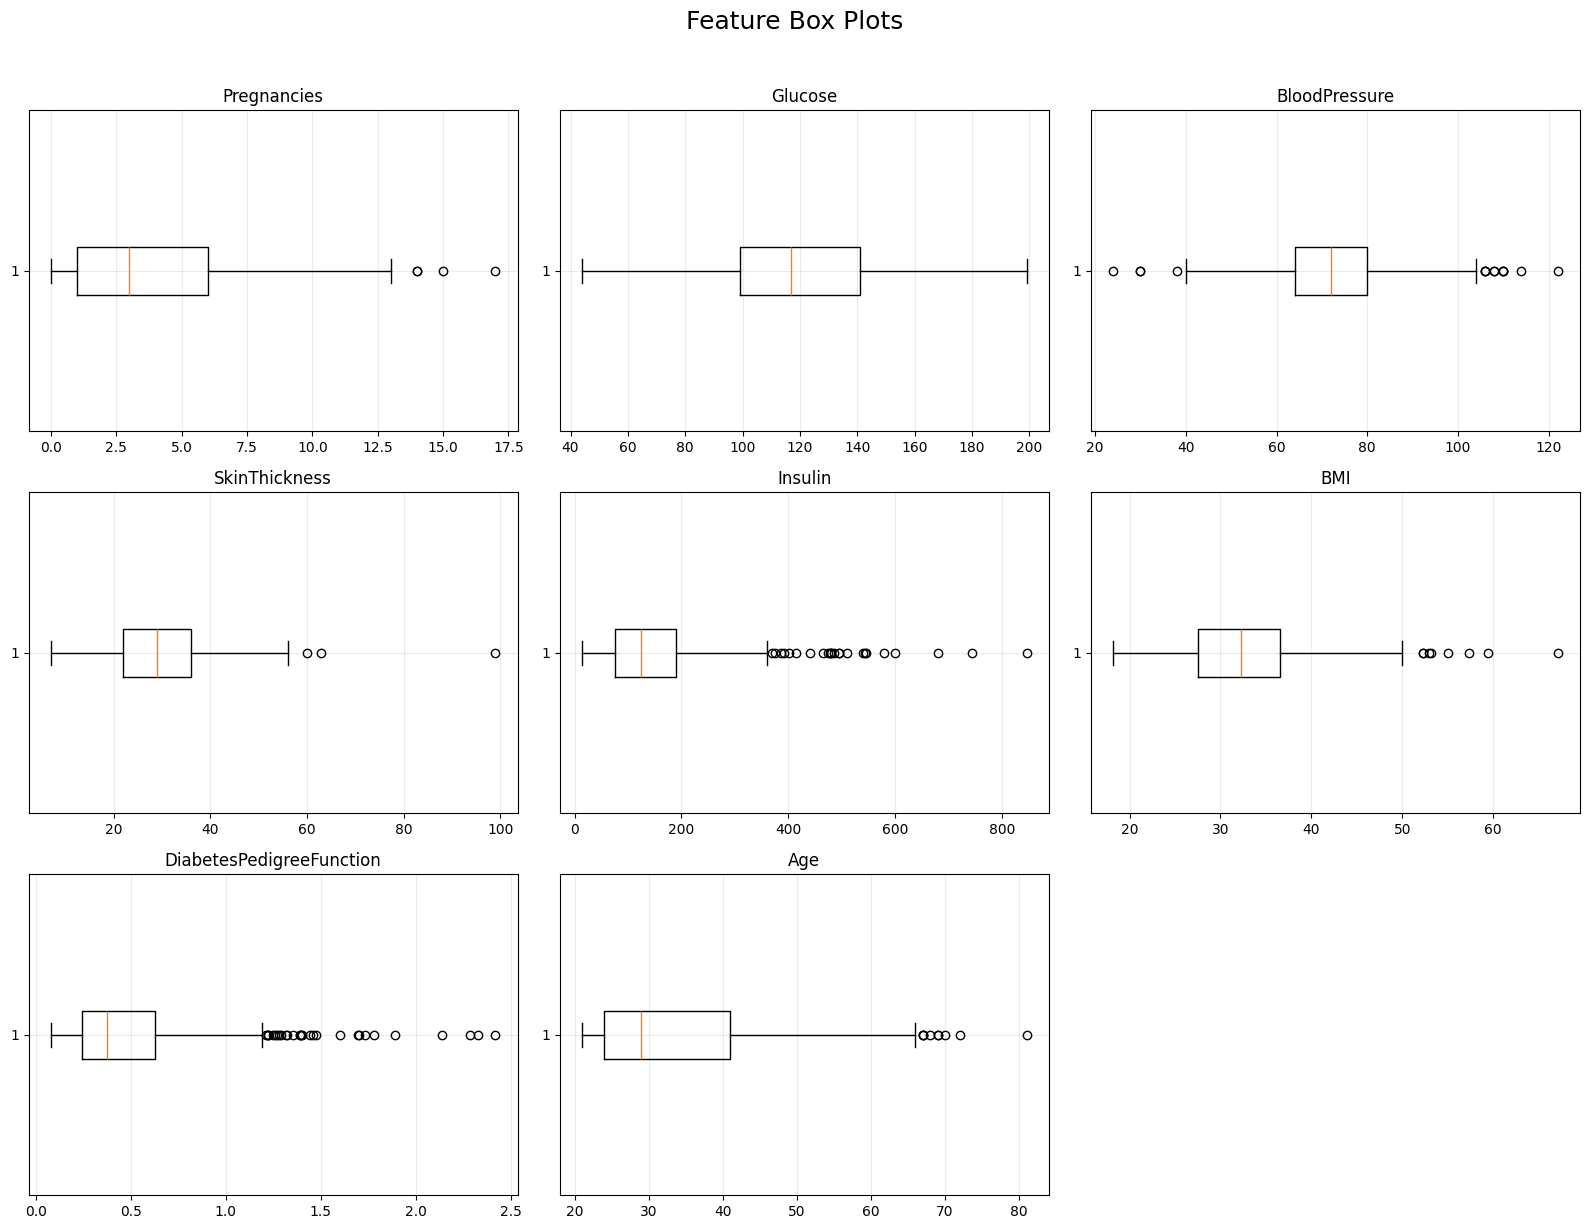

In [11]:
# check for outliers using box plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()
fig.suptitle("Feature Box Plots", fontsize=18, y=1.02)
for i, feature in enumerate(features):
    ax = axes[i]
    x = df[feature].dropna()
    ax.boxplot(x, vert=False)
    ax.set_title(feature, fontsize=12)
    ax.grid(True, alpha=0.25)
# Turn off empty axes (if any)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()  


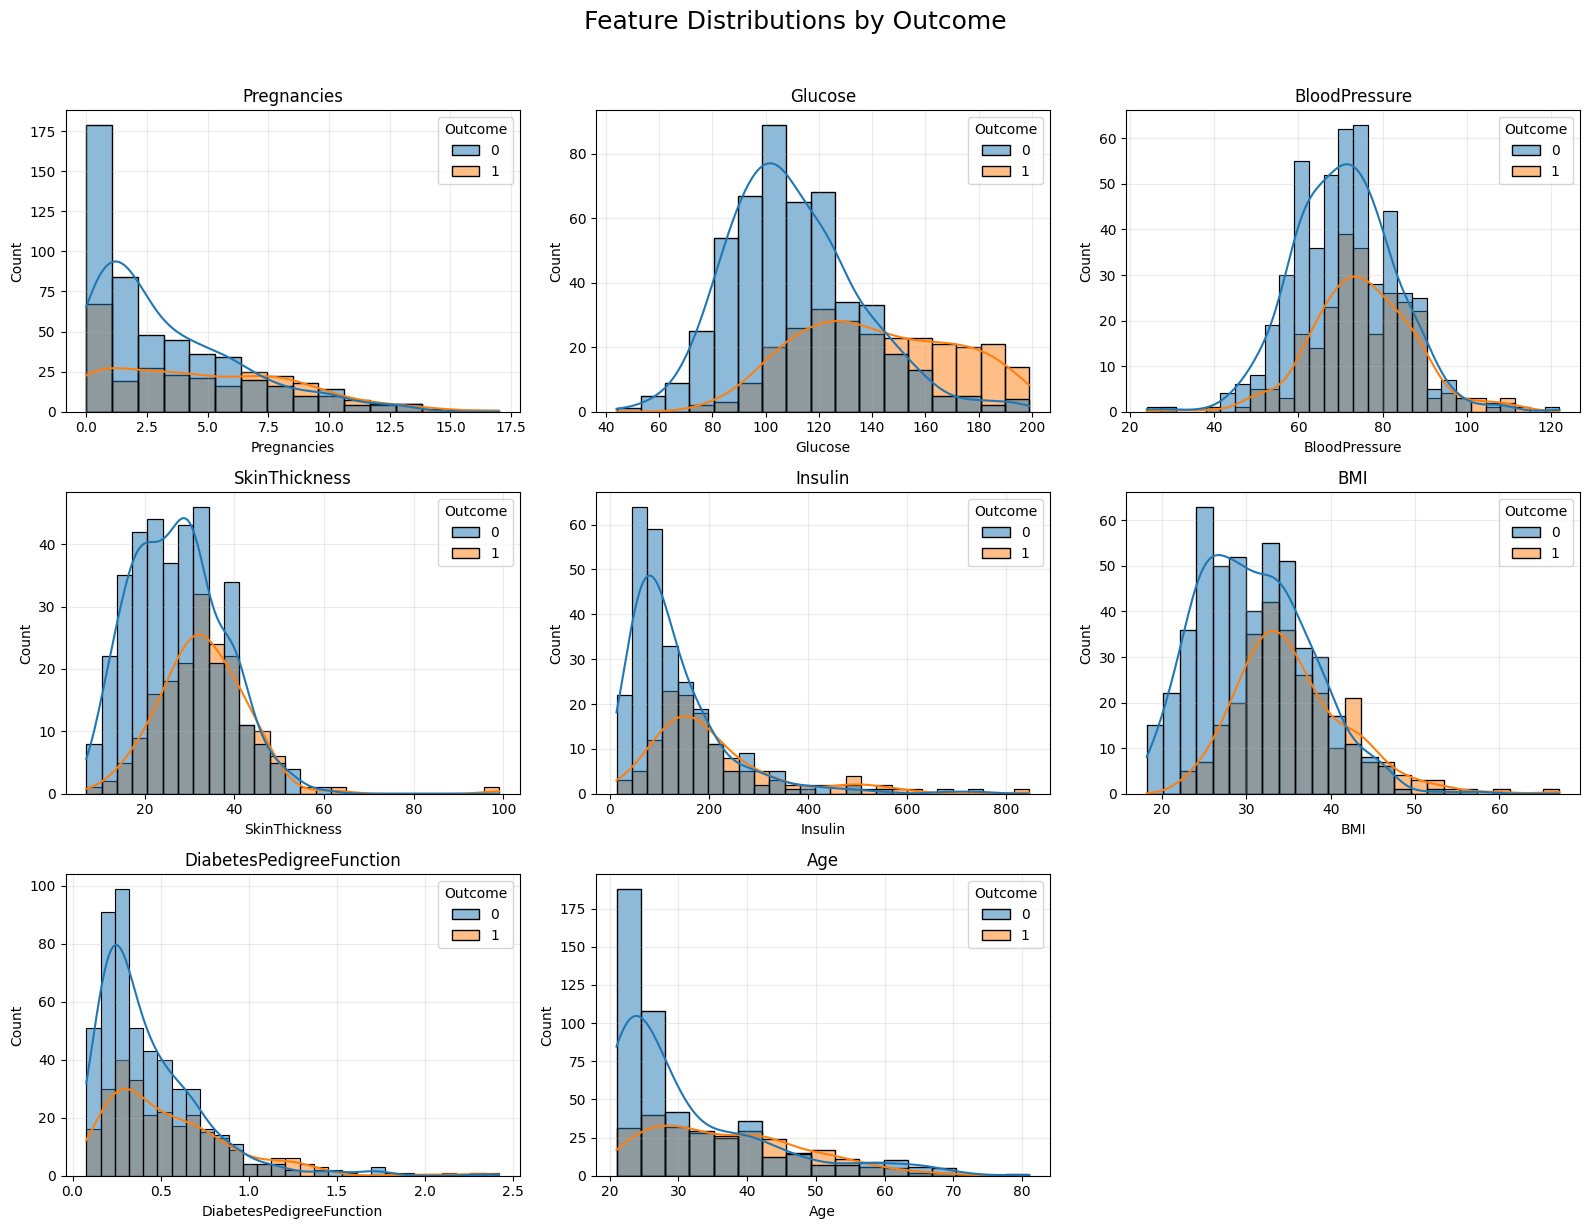

In [12]:
# feature vs target distribution
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()
fig.suptitle("Feature Distributions by Outcome", fontsize=18, y=1.02)
for i, feature in enumerate(features):
    ax = axes[i]
    sns.histplot(data=df, x=feature, hue="Outcome", kde=True, ax=ax)
    ax.set_title(feature, fontsize=12)
    ax.grid(True, alpha=0.25)
# Turn off empty axes (if any)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()


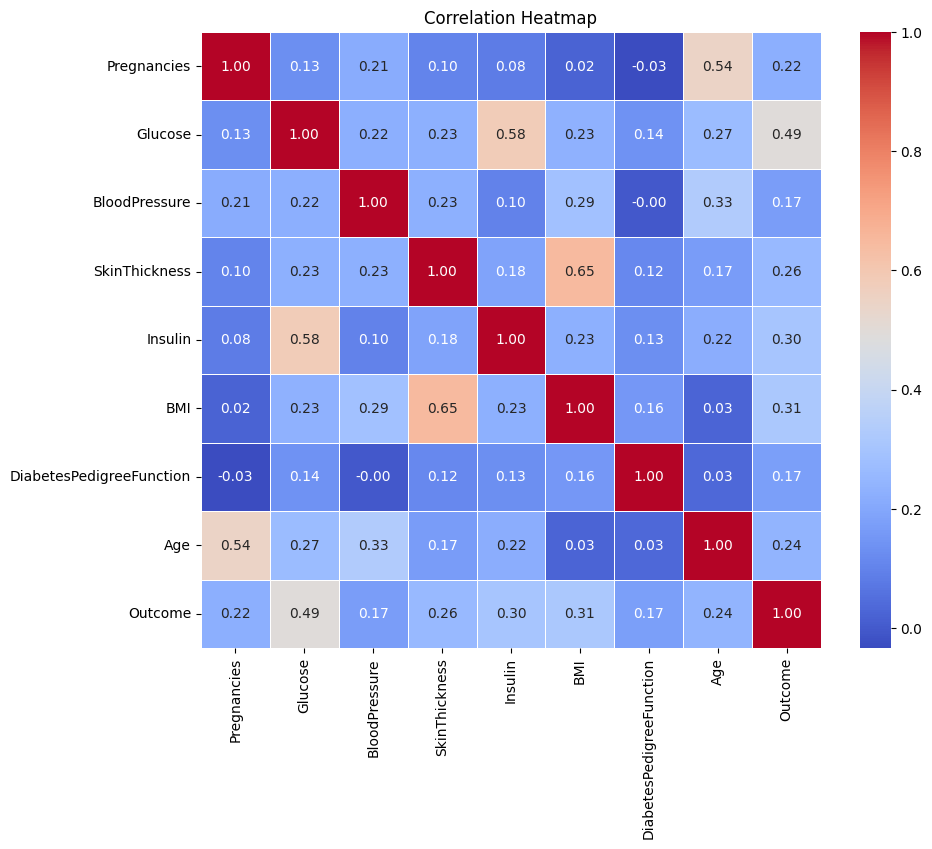

In [13]:
# correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
# Train Test Split
from sklearn.model_selection import train_test_split
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((614, 8), (614,), (154, 8), (154,))

In [15]:
# Logistic Regression baseline (with NaN imputation + scaling)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Pipeline: Impute -> Scale -> Logistic Regression
lr_pipe = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),  # impute missing values with median
        ("scaler", StandardScaler()),  # scale features
        (
            "classifier",
            LogisticRegression(max_iter=1000, class_weight="balanced"),
        ),  # logistic regression model
    ]
)

# train the model
lr_pipe.fit(X_train, y_train)

# evaluate the model
y_pred = lr_pipe.predict(X_test)
y_proba = lr_pipe.predict_proba(X_test)[:, 1]
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
 [[75 25]
 [16 38]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154


ROC-AUC: 0.8125925925925926


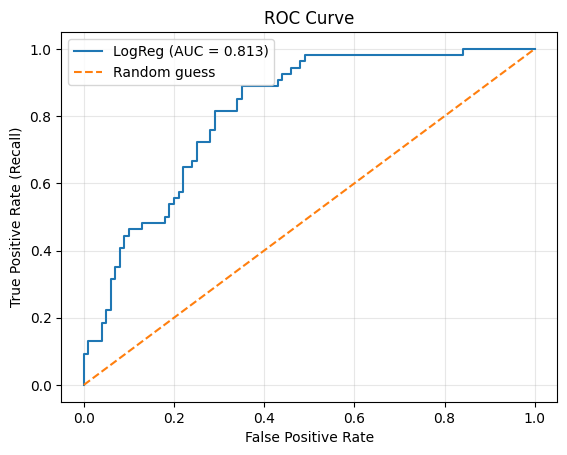

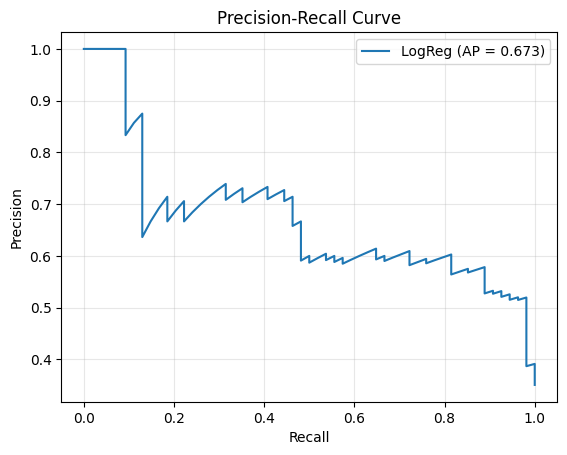

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

# probabilities for class 1
y_proba = lr_pipe.predict_proba(X_test)[:, 1]

# -------- ROC Curve --------
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"LogReg (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -------- Precision-Recall Curve --------
prec, rec, pr_thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure()
plt.plot(rec, prec, label=f"LogReg (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# Tune Lr with GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__penalty": ["l1", "l2"],
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear"],  # supports both l1 and l2
    "classifier__class_weight": [None, "balanced"],
}

grid = GridSearchCV(
    lr_pipe,
    param_grid=param_grid,
    scoring="roc_auc", 
    cv=5,
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

best_lr = grid.best_estimator_

Best params: {'classifier__C': 1, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV ROC-AUC: 0.8430564784053155


d:\Coding\Projects\Diabetes Prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [18]:
# evaluate tuned LR on test set

y_pred = best_lr.predict(X_test)
y_proba = best_lr.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nTest ROC-AUC:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
 [[80 20]
 [27 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.80      0.77       100
           1       0.57      0.50      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154


Test ROC-AUC: 0.8127777777777777


In [19]:
# use XGBoost model
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
)

xgb_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),  # safe even if NaNs exist
        ("model", xgb),
    ]
)

xgb_pipe.fit(X_train, y_train)

y_pred = xgb_pipe.predict(X_test)
y_proba = xgb_pipe.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_proba))

Confusion Matrix:
 [[83 17]
 [20 34]]

Report:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82       100
           1       0.67      0.63      0.65        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154


ROC-AUC: 0.8157407407407407


In [20]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [300, 500, 800, 1200],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train, y_train)
best_xgb = search.best_estimator_
print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

y_proba = best_xgb.predict_proba(X_test)[:, 1]
y_pred = best_xgb.predict(X_test)
print("\nTest ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Best params: {'model__subsample': 1.0, 'model__reg_lambda': 2.0, 'model__n_estimators': 1200, 'model__max_depth': 2, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
Best CV ROC-AUC: 0.8340753045404208

Test ROC-AUC: 0.8235185185185185

Confusion Matrix:
 [[86 14]
 [23 31]]

Report:
               precision    recall  f1-score   support

           0       0.79      0.86      0.82       100
           1       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154

